In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('train.csv')
data = np.array(data)

m, n = data.shape
np.random.shuffle(data)

# Dev set
data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n] / 255.0   # ✅ NORMALIZATION

# Train set
data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n] / 255.0   # ✅ NORMALIZATION

In [3]:
def init_params():
    W1 = np.random.randn(64, 784) * np.sqrt(2/784)
    b1 = np.zeros((64, 1))

    W2 = np.random.randn(10, 64) * np.sqrt(2/64)
    b2 = np.zeros((10, 1))

    return W1, b1, W2, b2

In [4]:
def ReLU(Z):
    return np.maximum(0, Z)

def deriv_ReLU(Z):
    return Z > 0

def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z_shift)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

In [5]:
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1 @ X + b1
    A1 = ReLU(Z1)

    Z2 = W2 @ A1 + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

In [6]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

In [7]:
def backward_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)

    dZ2 = A2 - one_hot_Y
    dW2 = 1/m * dZ2 @ A1.T
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)   # ✅ FIXED

    dZ1 = W2.T @ dZ2 * deriv_ReLU(Z1)
    dW1 = 1/m * dZ1 @ X.T
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)   # ✅ FIXED

    return dW1, db1, dW2, db2

In [8]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2

    return W1, b1, W2, b2

In [9]:
def get_predictions(A2):
    return np.argmax(A2, axis=0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

In [10]:
def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        if i % 100 == 0:
            print("Iteration:", i)
            print("Accuracy:", get_accuracy(get_predictions(A2), Y))

    return W1, b1, W2, b2

In [11]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.1, 1000)

Iteration: 0
Accuracy: 0.1023170731707317
Iteration: 100
Accuracy: 0.8789268292682927
Iteration: 200
Accuracy: 0.8981463414634147
Iteration: 300
Accuracy: 0.9076341463414634
Iteration: 400
Accuracy: 0.9143658536585366
Iteration: 500
Accuracy: 0.9204146341463415
Iteration: 600
Accuracy: 0.9250487804878049
Iteration: 700
Accuracy: 0.9290487804878049
Iteration: 800
Accuracy: 0.9324878048780488
Iteration: 900
Accuracy: 0.9350243902439025


In [12]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    return get_predictions(A2)

def test_prediction(index):
    current_image = X_train[:, index, None]
    prediction = make_predictions(current_image, W1, b1, W2, b2)
    label = Y_train[index]

    print("Prediction:", prediction)
    print("Label:", label)

    plt.gray()
    plt.imshow(current_image.reshape(28,28), interpolation='nearest')
    plt.show()

In [14]:
train_predictions = make_predictions(X_train, W1, b1, W2, b2)
print("Training Accuracy:", get_accuracy(train_predictions, Y_train))

dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
print("Validation Accuracy:", get_accuracy(dev_predictions, Y_dev))

Training Accuracy: 0.9373902439024391
Validation Accuracy: 0.937


In [15]:
def test_prediction(index):
    current_image = X_train[:, index, None]
    prediction = make_predictions(current_image, W1, b1, W2, b2)
    label = Y_train[index]

    print("Prediction:", prediction[0])
    print("Actual Label:", label)

    plt.gray()
    plt.imshow(current_image.reshape(28,28), interpolation='nearest')
    plt.show()

Prediction: 5
Actual Label: 5


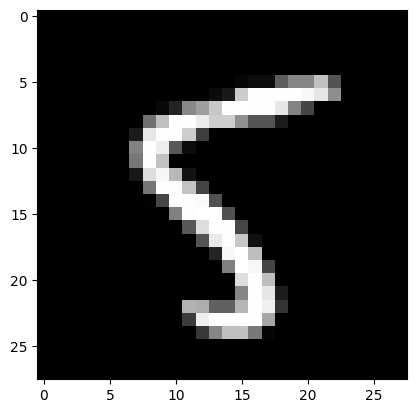

In [16]:
test_prediction(0)

Prediction: 0
Actual Label: 0


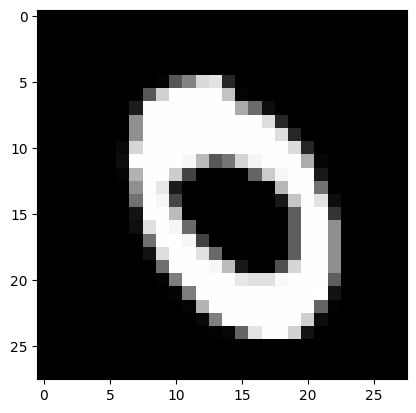

Prediction: 3
Actual Label: 3


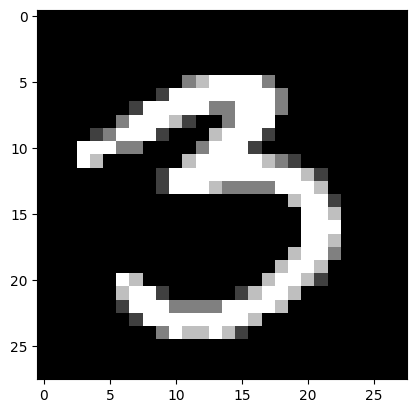

In [17]:
test_prediction(15)
test_prediction(100)